# Chemistry Generation Demo

This notebook is the maintained chemistry-focused EqM demo.

It is tailored to molecular graph generation:
- it uses PubChem molecular graphs only,
- it uses molecule drawing instead of artificial graph rendering,
- it keeps edge-label supervision enabled,
- it relies on node-existence masking so generated graphs can have variable numbers of nodes.

In [6]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2

import os
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore", message=".*PossibleUserWarning.*")
warnings.filterwarnings("ignore", message=".*does not have many workers.*")
warnings.filterwarnings("ignore", message=".*to enable TensorBoard support.*")

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import torch
from IPython.core.display import HTML

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')

_repo_candidates = [Path.cwd(), Path.cwd().parent]
for _root in _repo_candidates:
    if (_root / 'eqm_decompositional_graph_generator').exists():
        REPO_ROOT = _root.resolve()
        if str(REPO_ROOT) not in sys.path:
            sys.path.insert(0, str(REPO_ROOT))
        break
else:
    raise ModuleNotFoundError("Could not locate 'eqm_decompositional_graph_generator'.")

_nsppk_candidates = []
if os.environ.get("NSPPK_ROOT"):
    _nsppk_candidates.append(Path(os.environ["NSPPK_ROOT"]).expanduser())
_nsppk_candidates.extend([
    REPO_ROOT / 'NSPPK',
    REPO_ROOT.parent / 'NSPPK',
    Path.cwd() / 'NSPPK',
    Path.cwd().parent / 'NSPPK',
])
for _nsppk_root in _nsppk_candidates:
    _candidate = _nsppk_root.resolve()
    if _candidate.exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise ModuleNotFoundError("Could not locate NSPPK. Set NSPPK_ROOT or clone NSPPK next to this repo.")

ARTIFACT_ROOT = REPO_ROOT / '.artifacts'
CHECKPOINT_ROOT = ARTIFACT_ROOT / 'checkpoints' / 'eqm'

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(torch.cuda.current_device())}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PyTorch version: 2.5.0+cpu
CUDA available: False


In [7]:
from coco_grape.visualizer.mol_display import draw_molecules


def show_molecules(graphs, n=12, title=None):
    graphs = list(graphs)[:n]
    if title:
        print(title)
    if not graphs:
        print("No graphs to display.")
        return
    draw_molecules(graphs)


def label_counter(graphs, kind="node"):
    counts = {}
    if kind == "node":
        for graph in graphs:
            for _, attrs in graph.nodes(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    elif kind == "edge":
        for graph in graphs:
            for _, _, attrs in graph.edges(data=True):
                label = attrs.get("label")
                counts[label] = counts.get(label, 0) + 1
    else:
        raise ValueError("kind must be 'node' or 'edge'")
    return dict(sorted(counts.items(), key=lambda item: str(item[0])))


def summarize_graphs(graphs, targets=None, prefix="dataset"):
    node_counts = np.array([graph.number_of_nodes() for graph in graphs], dtype=int)
    edge_counts = np.array([graph.number_of_edges() for graph in graphs], dtype=int)
    print(f"{prefix}: {len(graphs)} graphs")
    if targets is not None:
        print(f"{prefix}: class counts = {dict(zip(*np.unique(targets, return_counts=True)))}")
    print(
        f"{prefix}: node count min/median/max = "
        f"{node_counts.min()}/{int(np.median(node_counts))}/{node_counts.max()}"
    )
    print(
        f"{prefix}: edge count min/median/max = "
        f"{edge_counts.min()}/{int(np.median(edge_counts))}/{edge_counts.max()}"
    )
    print(f"{prefix}: node labels = {label_counter(graphs, 'node')}")
    print(f"{prefix}: edge labels = {label_counter(graphs, 'edge')}")


def show_seed_and_samples(graph_generator, seed_graphs, n_seeds=6, title="Samples", apply_feasibility_filtering=True):
    seed_graphs = list(seed_graphs)[:n_seeds]
    show_molecules(seed_graphs, n=n_seeds, title=f"{title}: conditioning molecules")
    sampled = graph_generator.sample_conditioned_on_random(
        seed_graphs,
        n_samples=n_seeds,
        apply_feasibility_filtering=apply_feasibility_filtering,
    )
    show_molecules(sampled, n=n_seeds, title=f"{title}: generated molecules")
    return sampled


def inspect_predicted_masks_and_edge_labels(graph_generator, graphs, n_graphs=6):
    graph_conditioning = graph_generator.graph_encode(list(graphs)[:n_graphs])
    generated_nodes = graph_generator.conditional_node_generator_model.predict(graph_conditioning)

    observed_node_counts = graph_conditioning.node_counts[:n_graphs]
    predicted_node_counts = generated_nodes.node_presence_mask[:n_graphs].sum(axis=1)
    mask_frame = pd.DataFrame(
        {
            "conditioning_nodes": observed_node_counts,
            "predicted_nodes": predicted_node_counts,
            "conditioning_edges": graph_conditioning.edge_counts[:n_graphs],
        }
    )
    display(mask_frame)

    edge_label_matrices = generated_nodes.edge_label_matrices
    if edge_label_matrices is None:
        print("No edge-label matrices were predicted.")
    else:
        summaries = []
        for idx, matrix in enumerate(edge_label_matrices[:n_graphs]):
            labels, counts = np.unique(np.asarray(matrix, dtype=object), return_counts=True)
            summaries.append({"graph_idx": idx, **{str(label): int(count) for label, count in zip(labels, counts)}})
        display(pd.DataFrame(summaries).fillna(0).astype({"graph_idx": int}))

    decoded = graph_generator.graph_decoder.decode(
        generated_nodes,
        predicted_node_labels_list=generated_nodes.node_labels,
        predicted_edge_probability_matrices=generated_nodes.edge_probability_matrices,
        predicted_edge_label_matrices=generated_nodes.edge_label_matrices,
    )
    show_molecules(decoded, n=n_graphs, title="Decoded molecules from the inspected latent batch")
    return generated_nodes, decoded

## Data

The dataset loader below keeps only real molecular graphs. Artificial graph branches are removed from this notebook.

[14:30:57] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 6 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 7 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[14:30:58] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 9 ignored
[14:30:59] Warning: ambiguous stereochemistry - overlapping neighbors  - at atom 8 ignored
[14:31:00] WARNING: not removing hydrogen atom without neighbors


pubchem: 158 graphs
pubchem: class counts = {np.int64(0): np.int64(99), np.int64(1): np.int64(59)}
pubchem: node count min/median/max = 10/19/20
pubchem: edge count min/median/max = 10/20/23
pubchem: node labels = {'Br': 13, 'C': 2049, 'Cl': 39, 'F': 5, 'I': 2, 'N': 354, 'O': 383, 'S': 35}
pubchem: edge labels = {'1': 1422, '2': 253, '3': 15, 'AROMATIC': 1359}
Example training molecules


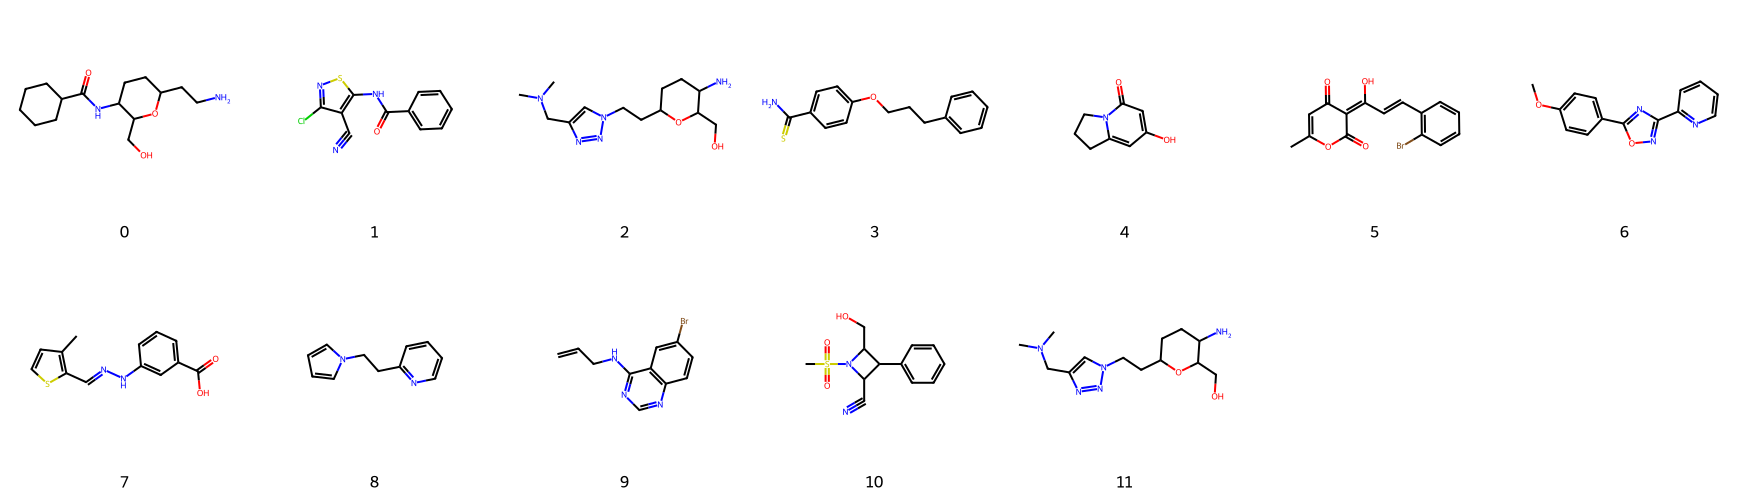

train_graphs=151 test_graphs=7
DEBUG_MODE active: train_graphs=64 test_graphs=7
Debug subset training molecules


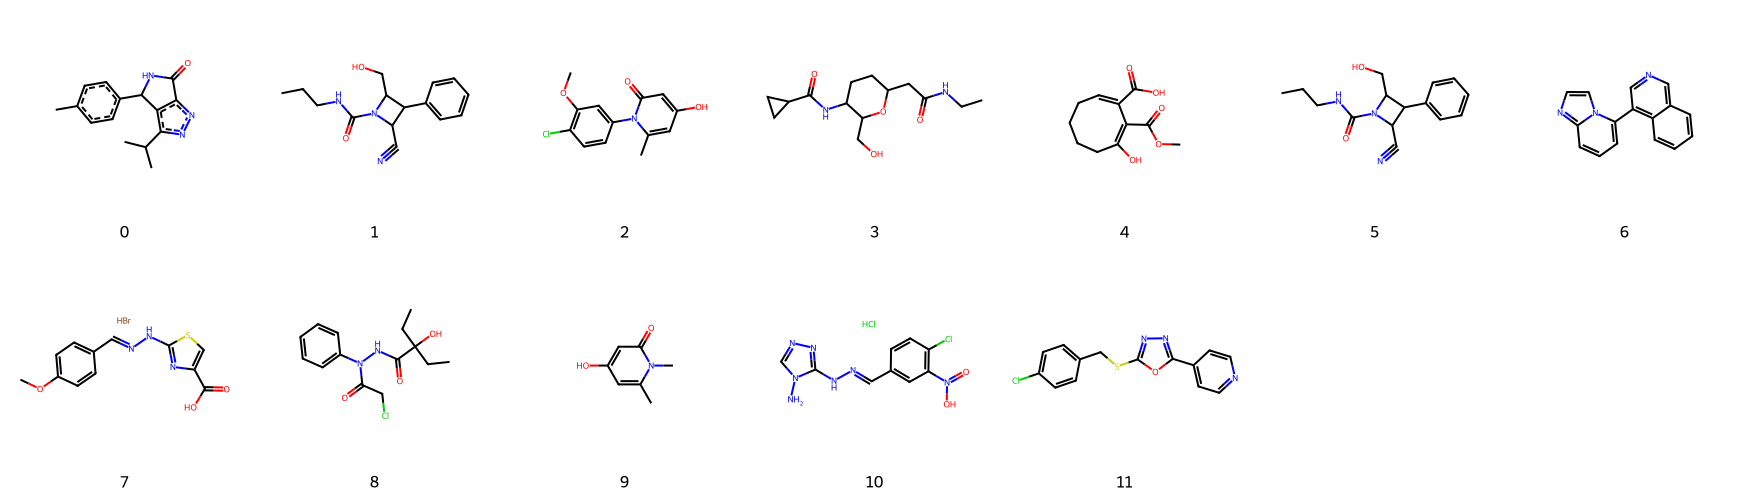

In [8]:
from coco_grape.data_loader.loader import SupervisedDataSetLoader
from coco_grape.data_loader.mol.mol_loader import PubChemLoader
from sklearn.model_selection import train_test_split
ASSAY_ID = '651610'
DATASET_SIZE = 6000
MAX_NODE_COUNT = 20
TEST_SIZE = 7
RANDOM_STATE = 42
DEBUG_MODE = True
DEBUG_TRAIN_SUBSET = 64
DEBUG_TEST_SUBSET = 16
def load_pubchem_dataset(assay_id=ASSAY_ID, dataset_size=DATASET_SIZE, max_node_count=MAX_NODE_COUNT):
    def pubchem_loader():
        return PubChemLoader().load(assay_id)
    original_graphs, original_targets = SupervisedDataSetLoader(
        pubchem_loader,
        size=dataset_size,
        use_equalized=False,
    ).load()
    original_graphs = np.asarray(original_graphs, dtype=object)
    original_targets = np.asarray(original_targets)
    keep = np.array([graph.number_of_nodes() <= max_node_count for graph in original_graphs], dtype=bool)
    graphs = original_graphs[keep].tolist()
    targets = original_targets[keep]
    return graphs, targets
graphs, targets = load_pubchem_dataset()
summarize_graphs(graphs, targets, prefix="pubchem")
show_molecules(graphs, n=12, title="Example training molecules")
train_graphs, test_graphs, train_targets, test_targets = train_test_split(
    graphs,
    targets,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=targets,
)
print(f"train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
if DEBUG_MODE:
    rng = np.random.default_rng(RANDOM_STATE)
    train_idx = rng.choice(len(train_graphs), size=min(DEBUG_TRAIN_SUBSET, len(train_graphs)), replace=False)
    test_idx = rng.choice(len(test_graphs), size=min(DEBUG_TEST_SUBSET, len(test_graphs)), replace=False)
    train_graphs = [train_graphs[int(i)] for i in train_idx]
    test_graphs = [test_graphs[int(i)] for i in test_idx]
    train_targets = np.asarray(train_targets)[train_idx]
    test_targets = np.asarray(test_targets)[test_idx]
    print(f"DEBUG_MODE active: train_graphs={len(train_graphs)} test_graphs={len(test_graphs)}")
    show_molecules(train_graphs, n=12, title="Debug subset training molecules")


## Model

This configuration is explicitly chemistry-oriented:
- `use_edges_as_features=True` so molecular bond labels are encoded,
- `lambda_edge_label_importance` is non-zero so bond labels are learned,
- `lambda_node_exist_importance` is non-zero so variable-size generation uses the predicted node mask,
- the full lambda surface is written out explicitly so additional consistency losses can be tuned in one place.

In [ ]:
from nsppk import NSPPK, NodeNSPPK

from AbstractGraph.abstract_graph_operators import compose, cycle, neighborhood, unlabel
from AbstractGraph.feasibility import (
    FeasibilityEstimator,
    FeasibilityEstimatorFeatureCannotExist,
    WithinRangeFeasibilityEstimatorFromNumericalFunction,
)

from eqm_decompositional_graph_generator.node_engine import EqMDecompositionalNodeGenerator
from eqm_decompositional_graph_generator.graph_engine import (
    EqMDecompositionalGraphDecoder,
    EqMDecompositionalGraphGenerator,
)

NBITS = 11
VERBOSE = 2

node_graph_vectorizer = NodeNSPPK(
    radius=2,
    distance=4,
    connector=1,
    nbits=NBITS,
    dense=True,
    parallel=True,
    use_edges_as_features=True,
)

graph_vectorizer = NSPPK(
    radius=2,
    distance=4,
    connector=1,
    nbits=NBITS,
    dense=True,
    parallel=True,
    use_edges_as_features=True,
)

feasibility_size = WithinRangeFeasibilityEstimatorFromNumericalFunction(
    numerical_function=lambda graph: len(graph),
    quantile=None,
)
feasibility_unlabeled_structure = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=compose(neighborhood(radius=2), unlabel()),
    nbits=19,
    parallel=True,
    backend="dill",
)
feasibility_valence = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=neighborhood(radius=1),
    nbits=19,
    parallel=True,
    backend="dill",
)
feasibility_cycle = FeasibilityEstimatorFeatureCannotExist(
    decomposition_function=cycle(),
    nbits=19,
    parallel=True,
    backend="dill",
)
feasibility_estimator = FeasibilityEstimator(
    [feasibility_size, feasibility_valence, feasibility_cycle, feasibility_unlabeled_structure]
)

conditional_node_generator_model = EqMDecompositionalNodeGenerator(
    latent_embedding_dimension=96,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    transformer_dropout=0.15,
    learning_rate=2e-4,
    maximum_epochs=200,
    batch_size=16,
    total_steps=100,
    
    lambda_direct_edge_importance=2e3,
    lambda_auxiliary_edge_importance=1e3,
    lambda_degree_importance=1e3,
    lambda_degree_edge_consistency_importance=5e2,
    lambda_node_exist_importance=1e3,
    lambda_node_count_importance=5e2,
    lambda_node_label_importance=1e3,
    lambda_edge_label_importance=2e3,
    lambda_edge_count_importance=1e3,
    
    degree_temperature=1.0,
    eqm_sigma=0.2,
    sampling_step_size=0.05,
    langevin_noise_scale=0.0,
    verbose=VERBOSE,
    verbose_epoch_interval=10,
    enable_early_stopping=True,
    early_stopping_monitor="val_total",
    early_stopping_mode="min",
    early_stopping_patience=30,
    early_stopping_min_delta=10.0,
    restore_best_checkpoint=True,
    artifact_root_dir=str(ARTIFACT_ROOT),
    checkpoint_root_dir=str(CHECKPOINT_ROOT),
)

graph_decoder = EqMDecompositionalGraphDecoder(
    verbose=VERBOSE,
    enforce_connectivity=True,
    warm_start_mst=True,
    n_jobs=4,
)

from notebooks.notebook_utils import sample_positive_endpoint_pair
graph_generator = EqMDecompositionalGraphGenerator(
    graph_vectorizer=graph_vectorizer,
    node_graph_vectorizer=node_graph_vectorizer,
    conditional_node_generator_model=conditional_node_generator_model,
    graph_decoder=graph_decoder,
    feasibility_estimator=feasibility_estimator,
    locality_sample_fraction=0.5,
    locality_horizon=1,
    negative_sample_factor=1,
    locality_sampling_strategy="stratified_preserve",
    locality_target_positive_ratio=0.5,
    max_feasibility_attempts=5,
    feasibility_candidates_per_attempt=16,
    feasibility_failure_mode="return_partial",
    verbose=VERBOSE,
)


## Fit

Fitting the graph generator now plans and trains four relevant supervision channels for chemistry:
- node labels,
- edge labels,
- direct edge presence,
- auxiliary locality.

The conditional EqM model also receives the per-graph `node_presence_mask`, which is what lets it generate variable-size molecular graphs.

Fitting model on 64 graphs
Fitting feasibility estimator on 64 graphs
Supervision plan:
  node_labels: mode=learned, enabled. 8 node labels detected.
  edge_labels: mode=learned, enabled. 4 edge labels detected.
  direct_edges: mode=learned, enabled, horizon=1. Generator should learn horizon-1 edge presence for the decoder.
  auxiliary_locality: mode=disabled, disabled. No auxiliary locality is needed when locality_horizon=1.
adj_mtx_to_targets[direct_edge, horizon=1]: sampling 7434 pairs (50.00%) from 14868 total pairs (pos=4956, neg=9912, negative_sample_factor=1, sampling_strategy=stratified_preserve, target_positive_ratio=0.500).
adj_mtx_to_targets[direct_edge, horizon=1]: using pos=2478, neg=4956, positive_ratio=0.333.
Training conditional model on 64 graphs with up to 20 nodes each.
Using direct-edge supervision with 7434 labelled pairs.


GPU available: False, used: False
TPU available: False, using: 0 TPU cores


Direct edge supervision enabled: horizon-1 edge presence will be learned and used by the decoder.
Soft edge-count supervision enabled: lambda_edge_count_importance=1000.000.
Soft node-count supervision enabled: lambda_node_count_importance=500.000.
Degree/edge-count consistency supervision enabled: lambda_degree_edge_consistency_importance=500.000.
Auxiliary locality supervision disabled: only direct edge supervision will be used; no extra locality head is trained.
Edge-label supervision enabled: discrete edge labels will be predicted by the generator.
Direct-edge BCE positive weight: 2.000.
ANN size: parameters=1,005,300, trainable=1,005,300.
Writing checkpoints to /mnt/data/sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_244449d2220f4d77ab485096221d0ada
Epoch 10/200 | ETA 0h 07m 05s:
  train total=  60259.0 |        eqm   51172.2 84.9% |        deg    1213.0  2.0% |      exist      93.6  0.2% | node_count     245.2  0.4% | node_label    1082.2  1.8% 

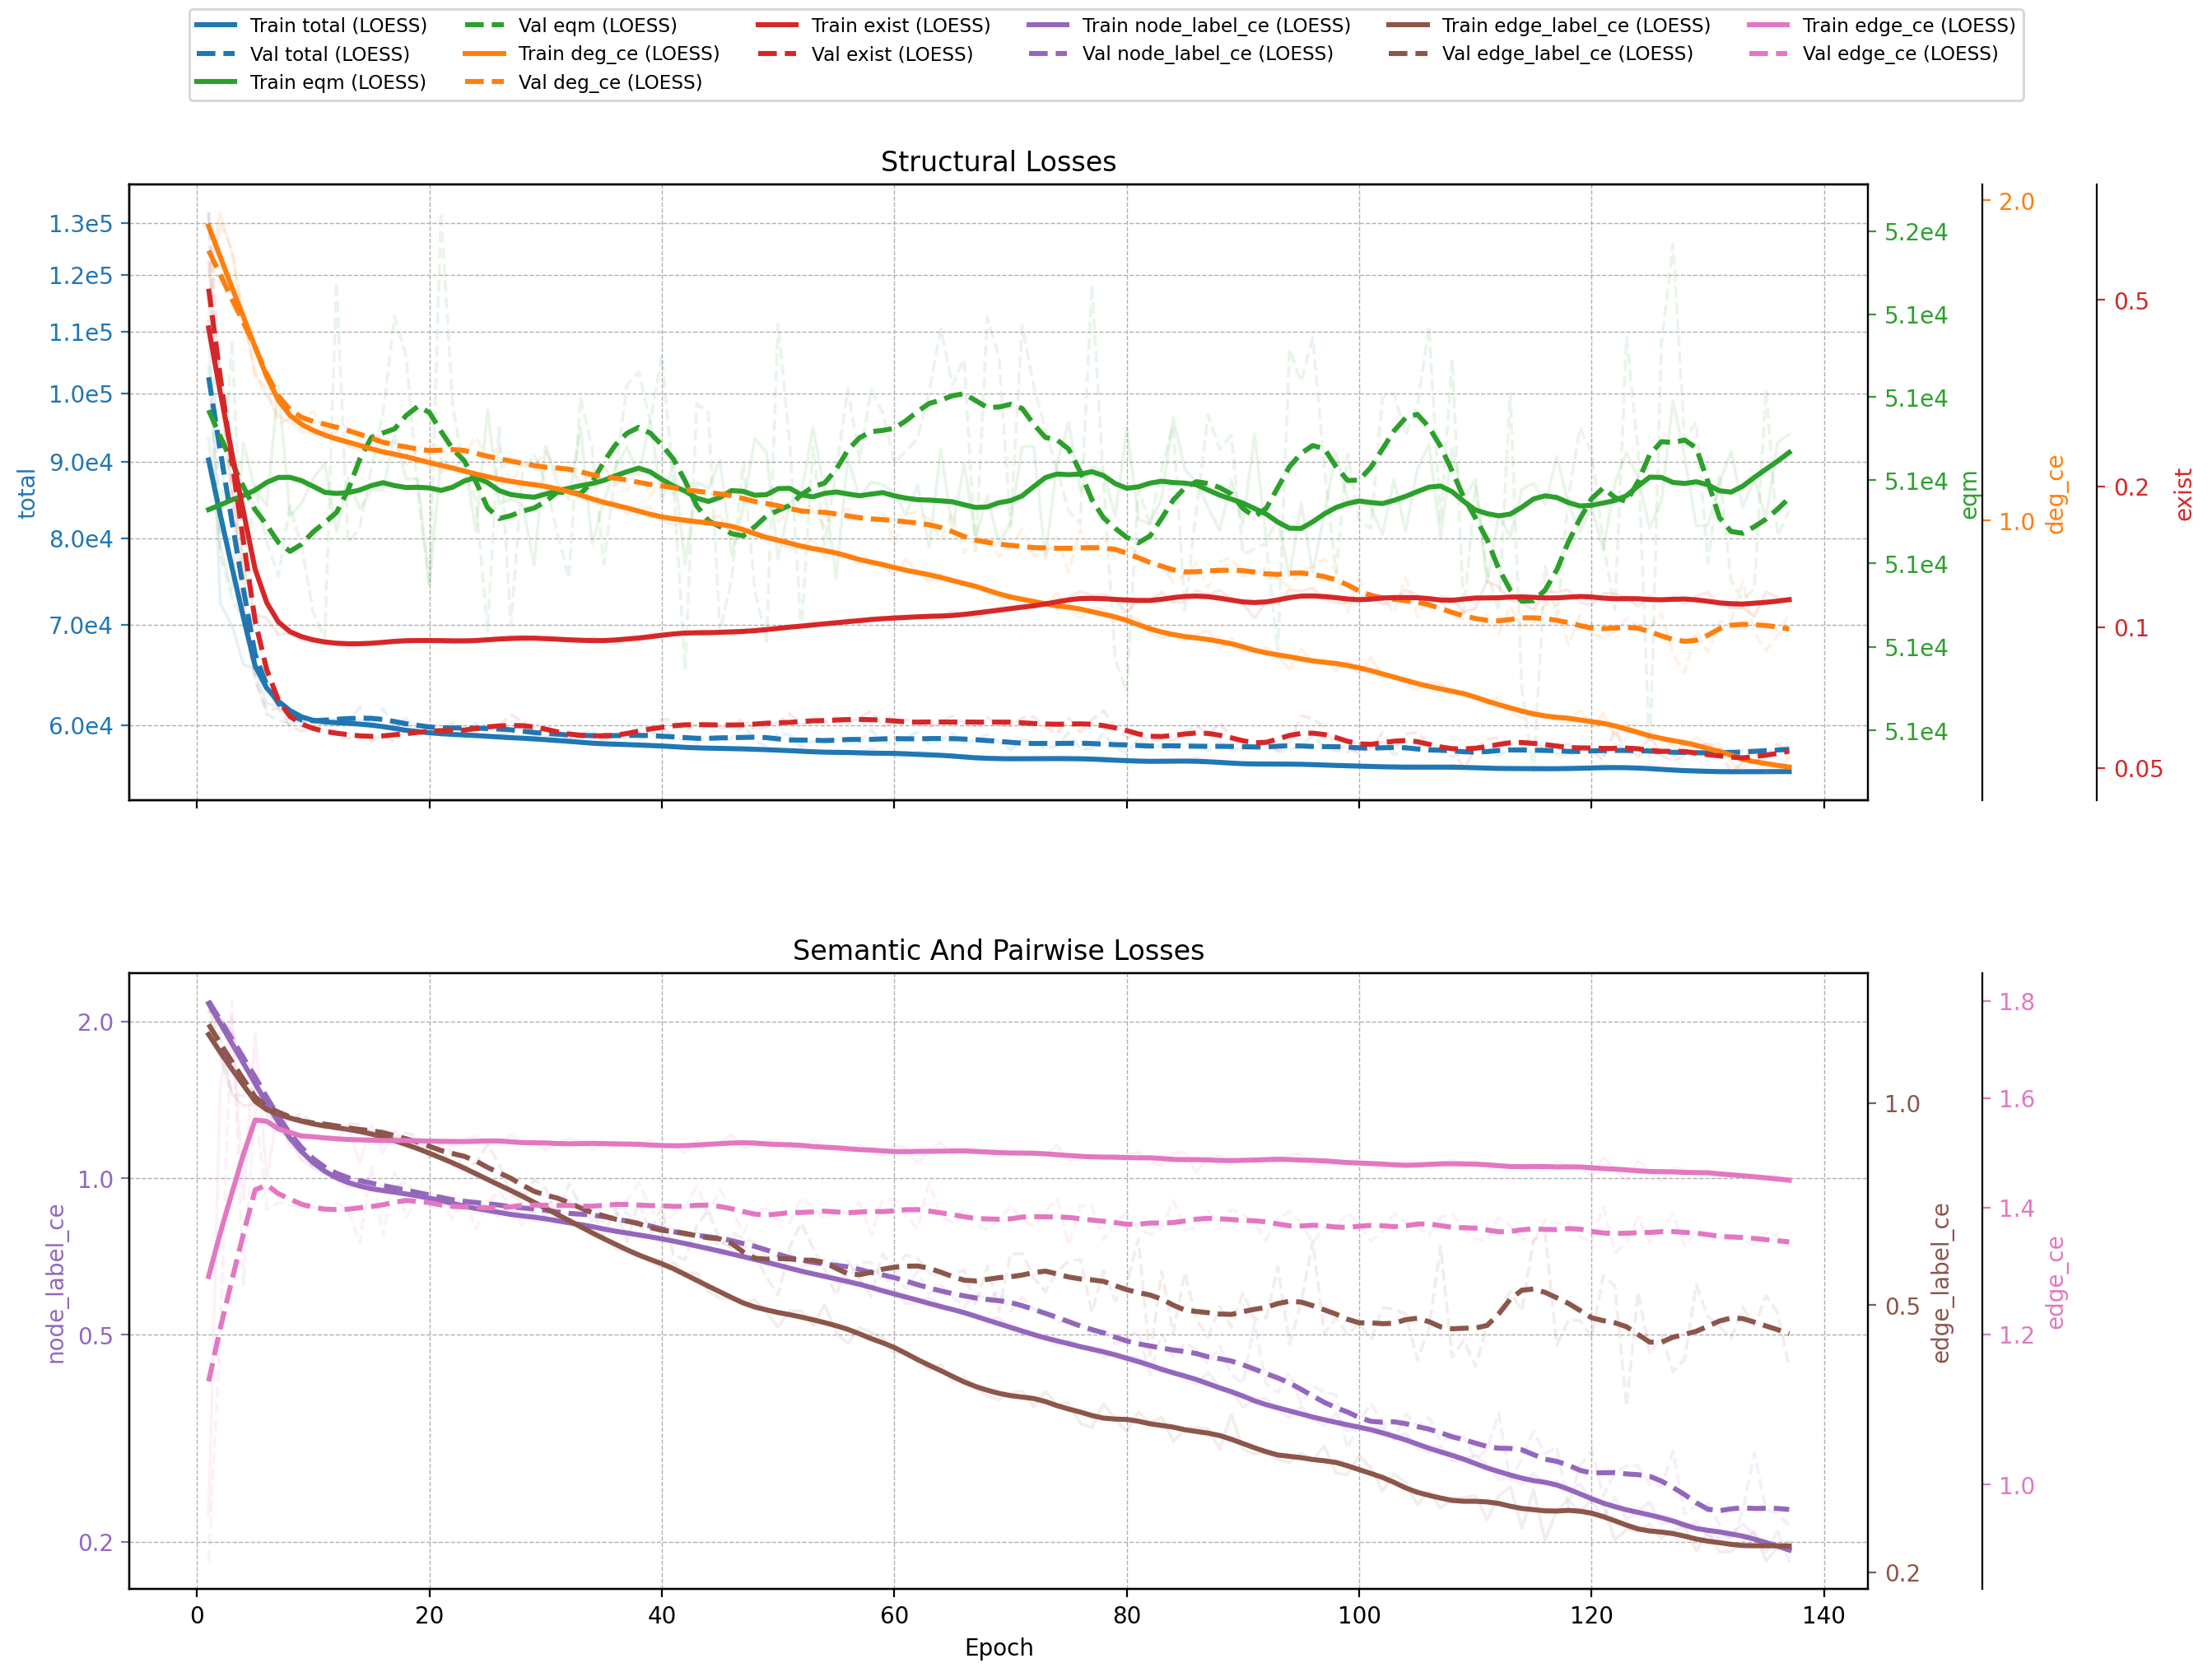

Restored best checkpoint: best_epoch=107, val_total=57124.6289, raw_val_eqm=51149.2734, stopped_epoch=138
  path=/mnt/data/sync/Projects/GraphGen/.artifacts/checkpoints/eqm/EqMDecompositionalNodeGenerator_244449d2220f4d77ab485096221d0ada/best-106-57124.6289.ckpt
CPU times: user 3h 12min 6s, sys: 2min 34s, total: 3h 14min 40s
Wall time: 6min 23s


/mnt/data/sync/Projects/GraphGen/eqm_decompositional_graph_generator/node_engine.py:2153: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(self.best_che

In [10]:
%%time
graph_generator.fit(train_graphs)

## Inspect Masking And Bond Labels

Before decoding, inspect the latent predictions directly.

This is the part that matters for the current chemistry setup:
- `node_presence_mask` controls the generated number of atoms,
- `edge_label_matrices` provide predicted bond labels for the decoder.

,conditioning_nodes,predicted_nodes,conditioning_edges
0,19,20,21
1,20,20,21
2,18,20,19
3,20,20,21
4,16,20,16
5,20,20,21


,graph_idx,1,2,AROMATIC
0,0,368,24,8
1,1,269,47,84
2,2,291,97,12
3,3,351,13,36
4,4,257,124,19
5,5,278,72,50


Decoded molecules from the inspected latent batch


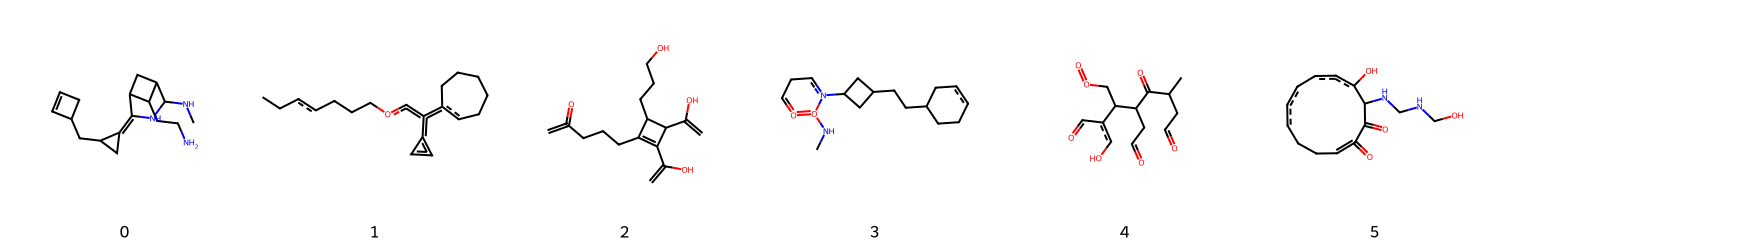

In [11]:
inspected_nodes, inspected_graphs = inspect_predicted_masks_and_edge_labels(
    graph_generator,
    train_graphs[:6],
    n_graphs=6,
)

## Conditional Molecule Sampling

The sampling examples below condition on real molecules and draw the generated molecules with the chemistry-specific routines.

Raw decoded molecules without feasibility filtering


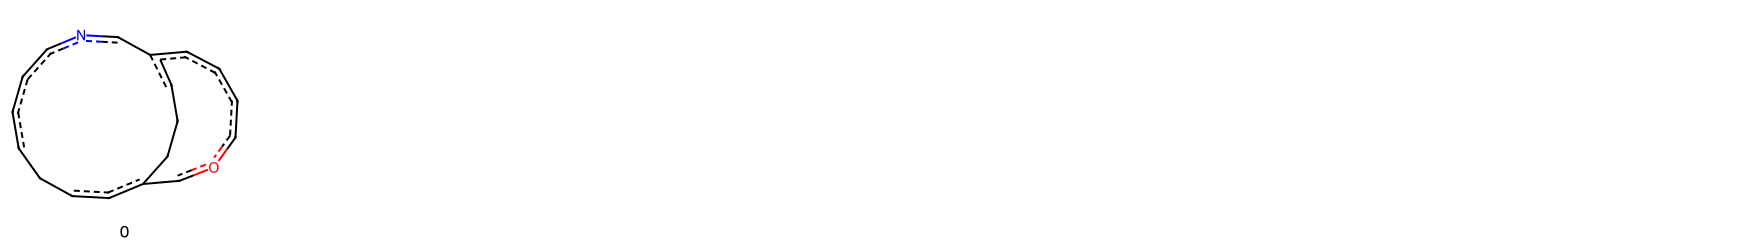

In [12]:
raw_samples = graph_generator.sample_conditioned_on_random(
    test_graphs,
    n_samples=1,
    apply_feasibility_filtering=False,
)
show_molecules(raw_samples, n=8, title="Raw decoded molecules without feasibility filtering")

Held-out conditioning set: conditioning molecules


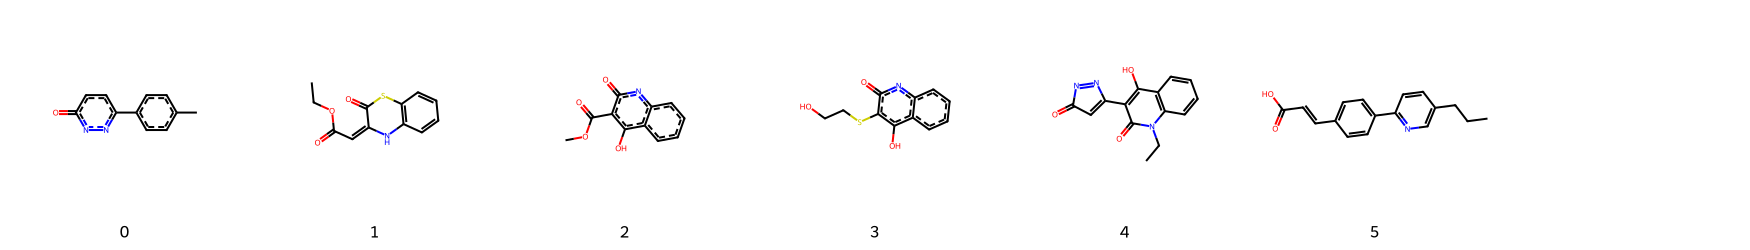

Feasibility attempt  1/5  | generated=  96 | accepted= 0 | rejected= 6 | rate=  0.0% | accepted_total= 0 | missing_total= 6


In [ ]:
show_seed_and_samples(
    graph_generator,
    test_graphs,
    n_seeds=6,
    title="Held-out conditioning set",
    apply_feasibility_filtering=True,
)

In [ ]:
active_seed_graphs = [graph for graph, target in zip(train_graphs, train_targets) if target == 1]
inactive_seed_graphs = [graph for graph, target in zip(train_graphs, train_targets) if target == 0]

active_samples = show_seed_and_samples(
    graph_generator,
    active_seed_graphs,
    n_seeds=6,
    title="Active class",
    apply_feasibility_filtering=True,
)

inactive_samples = show_seed_and_samples(
    graph_generator,
    inactive_seed_graphs,
    n_seeds=6,
    title="Inactive class",
    apply_feasibility_filtering=True,
)

## Positive Endpoint Interpolation

Select two active molecules at random, interpolate between them, and display the endpoints plus feasible generated molecules.

In [ ]:
selected_indices, selected_targets, endpoint_graph_a, endpoint_graph_b = sample_positive_endpoint_pair(
    train_graphs,
    train_targets,
)
print("Endpoint indices:", selected_indices)
print("Endpoint targets:", selected_targets)

show_molecules([endpoint_graph_a, endpoint_graph_b], n=2, title="Selected endpoint molecules")

interpolation_result = graph_generator.interpolate(
    endpoint_graph_a,
    endpoint_graph_b,
    k=3,
    apply_feasibility_filtering=True,
)
display(interpolation_result["summary"])

missing_steps = interpolation_result["summary"].loc[
    ~interpolation_result["summary"]["decoded"],
    "step",
].tolist()
if missing_steps:
    print("Interpolation steps rejected by feasibility filtering:", missing_steps)

show_molecules(
    [endpoint_graph_a, *interpolation_result["generated_graphs"], endpoint_graph_b],
    n=len(interpolation_result["generated_graphs"]) + 2,
    title="Endpoints and generated interpolation molecules",
)
